In [1]:
from __future__ import division, print_function
import sys, os, glob, time, warnings, gc
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table, vstack, hstack
import fitsio
# from astropy.io import fits

from scipy import stats
# from matplotlib.colors import LogNorm
import mpl_scatter_density
from astropy.visualization.mpl_normalize import ImageNormalize
from IPython.display import Image

In [2]:
params = {'legend.fontsize': 'x-large',
         'axes.labelsize': 'x-large',
         'axes.titlesize':'x-large',
         'xtick.labelsize':'x-large',
         'ytick.labelsize':'x-large',
         'figure.facecolor':'w'} 
plt.rcParams.update(params)

In [3]:
np.set_printoptions(precision=2)

In [4]:
basic_columns = ['TARGETID', 'RA', 'DEC', 'NOBS_G', 'NOBS_R', 'NOBS_Z', 'MASKBITS', 'PHOTSYS']
photom_columns = ['EBV', 'FLUX_G', 'FLUX_R', 'FLUX_Z', 'FLUX_W1', 'FLUX_W2', 'FIBERFLUX_Z', 'GAIA_PHOT_G_MEAN_MAG']

-------
# ELG

In [5]:
target_class = 'elg'
maskbits = [1, 11, 12, 13]

cat = []
for field in ['north', 'south']:
    t1 = Table(fitsio.read('/Users/rongpu/Documents/Data/desi_targets/dr9.0/combined/1.0.0/dr9_{}_{}_1.0.0_basic.fits'.format(target_class, field), columns=basic_columns))
    t2 = Table(fitsio.read('/Users/rongpu/Documents/Data/desi_targets/dr9.0/combined/1.0.0/dr9_{}_{}_1.0.0_photom.fits'.format(target_class, field), columns=photom_columns))
    cat.append(hstack([t1, t2], join_type='exact'))
cat = vstack(cat)

# Apply masks
mask_clean = np.ones(len(cat), dtype=bool)
for bit in maskbits:
    mask_clean &= (cat['MASKBITS'] & 2**bit)==0
cat = cat[mask_clean]

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    cat['gmag'] = 22.5 - 2.5*np.log10(cat['FLUX_G']) - 3.214 * cat['EBV']
    cat['rmag'] = 22.5 - 2.5*np.log10(cat['FLUX_R']) - 2.165 * cat['EBV']
    cat['zmag'] = 22.5 - 2.5*np.log10(cat['FLUX_Z']) - 1.211 * cat['EBV']
    cat['w1mag'] = 22.5 - 2.5*np.log10(cat['FLUX_W1']) - 0.184 * cat['EBV']
    cat['w2mag'] = 22.5 - 2.5*np.log10(cat['FLUX_W2']) - 0.113 * cat['EBV']

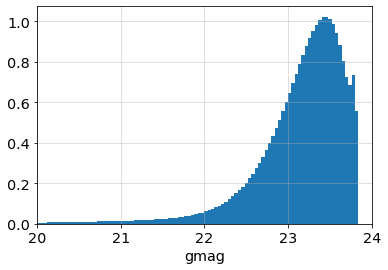

1st, 5th, 10th, 50th, 90th, 95th, 99th percentiles:
[21.04 22.18 22.53 23.27 23.69 23.76 23.82]


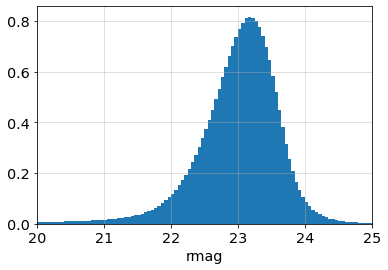

1st, 5th, 10th, 50th, 90th, 95th, 99th percentiles:
[20.95 21.96 22.28 23.08 23.66 23.83 24.3 ]


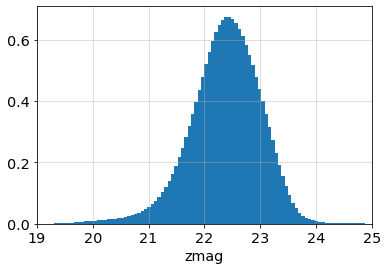

1st, 5th, 10th, 50th, 90th, 95th, 99th percentiles:
[20.48 21.29 21.59 22.41 23.14 23.32 23.68]


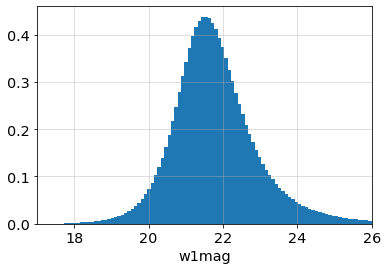

1st, 5th, 10th, 50th, 90th, 95th, 99th percentiles:
[19.29 20.15 20.53 21.68 23.23 23.9  25.56]


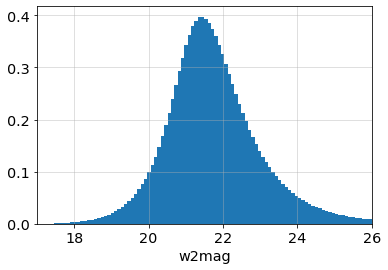

1st, 5th, 10th, 50th, 90th, 95th, 99th percentiles:
[19.   19.9  20.33 21.62 23.38 24.11 25.83]
GAIA fraction: 0.9%


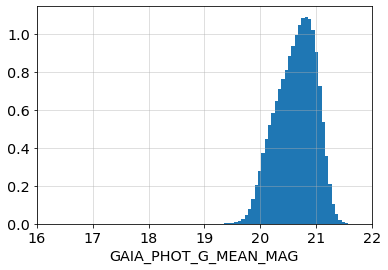

1st, 5th, 10th, 50th, 90th, 95th, 99th percentiles:
[19.83 20.03 20.15 20.67 21.07 21.15 21.29]


In [6]:
col_list = ['gmag', 'rmag', 'zmag', 'w1mag', 'w2mag', 'GAIA_PHOT_G_MEAN_MAG']
xlims = [[20, 24.], [20., 25], [19, 25.], [17, 26], [17, 26], [16, 22]]

for index in range(len(col_list)):
    col = col_list[index]
    v = cat[col]
    mask = np.isfinite(v)
    if col=='GAIA_PHOT_G_MEAN_MAG':
        mask &= cat[col]!=0
        print('GAIA fraction: {:.1f}%'.format(100*np.sum(mask)/len(mask)))
    v = v[mask]
    plt.hist(v, 100, range=xlims[index], density=True)
    plt.xlim(*xlims[index])
    plt.xlabel(col)
    plt.grid(alpha=0.5)
    plt.show()
    print('1st, 5th, 10th, 50th, 90th, 95th, 99th percentiles:')
    print(np.nanpercentile(v, [1, 5, 10, 50, 90, 95, 99]))

-------
# LRG

In [7]:
target_class = 'lrg'

cat = []
for field in ['north', 'south']:
    t1 = Table(fitsio.read('/Users/rongpu/Documents/Data/desi_targets/dr9.0/combined/1.0.0/dr9_{}_{}_1.0.0_basic.fits'.format(target_class, field), columns=basic_columns))
    t2 = Table(fitsio.read('/Users/rongpu/Documents/Data/desi_targets/dr9.0/combined/1.0.0/dr9_{}_{}_1.0.0_photom.fits'.format(target_class, field), columns=photom_columns))
    t3 = Table(fitsio.read('/Users/rongpu/Documents/Data/desi_targets/dr9.0/combined/1.0.0/dr9_{}_{}_1.0.0_lrgmask_v1.fits'.format(target_class, field)))
    cat.append(hstack([t1, t2, t3], join_type='exact'))
cat = vstack(cat)

# Apply masks
mask_clean = cat['lrg_mask']==0
cat = cat[mask_clean]

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    cat['gmag'] = 22.5 - 2.5*np.log10(cat['FLUX_G']) - 3.214 * cat['EBV']
    cat['rmag'] = 22.5 - 2.5*np.log10(cat['FLUX_R']) - 2.165 * cat['EBV']
    cat['zmag'] = 22.5 - 2.5*np.log10(cat['FLUX_Z']) - 1.211 * cat['EBV']
    cat['w1mag'] = 22.5 - 2.5*np.log10(cat['FLUX_W1']) - 0.184 * cat['EBV']
    cat['w2mag'] = 22.5 - 2.5*np.log10(cat['FLUX_W2']) - 0.113 * cat['EBV']

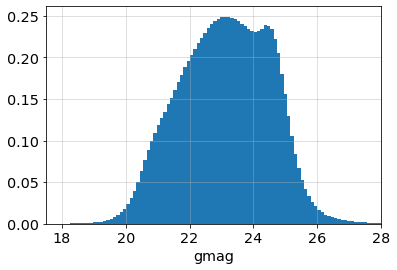

1st, 5th, 10th, 50th, 90th, 95th, 99th percentiles:
[20.11 20.79 21.21 23.17 24.88 25.23 26.09]


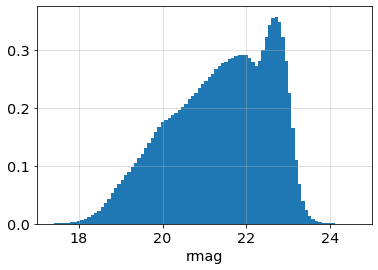

1st, 5th, 10th, 50th, 90th, 95th, 99th percentiles:
[18.59 19.23 19.66 21.53 22.85 23.01 23.28]


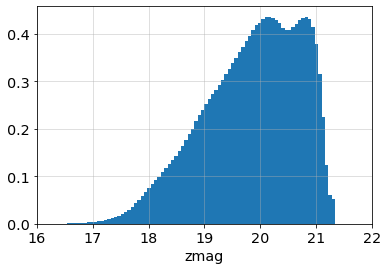

1st, 5th, 10th, 50th, 90th, 95th, 99th percentiles:
[17.67 18.25 18.62 19.96 20.91 21.03 21.19]


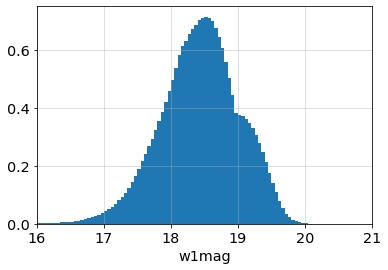

1st, 5th, 10th, 50th, 90th, 95th, 99th percentiles:
[16.95 17.45 17.68 18.46 19.2  19.37 19.61]


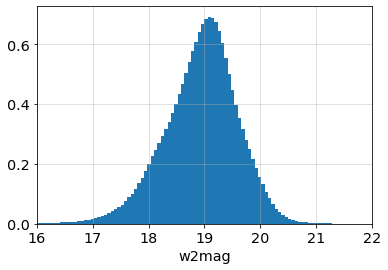

1st, 5th, 10th, 50th, 90th, 95th, 99th percentiles:
[17.13 17.79 18.08 18.99 19.73 19.94 20.33]
GAIA fraction: 1.1%


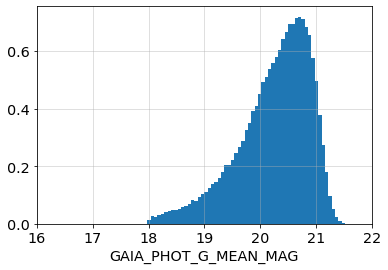

1st, 5th, 10th, 50th, 90th, 95th, 99th percentiles:
[18.34 18.96 19.33 20.37 20.96 21.07 21.23]


In [8]:
col_list = ['gmag', 'rmag', 'zmag', 'w1mag', 'w2mag', 'GAIA_PHOT_G_MEAN_MAG']
xlims = [[17.5, 28], [17., 25], [16, 22.], [16, 21], [16, 22], [16, 22]]

for index in range(len(col_list)):
    col = col_list[index]
    v = cat[col]
    mask = np.isfinite(v)
    if col=='GAIA_PHOT_G_MEAN_MAG':
        mask &= cat[col]!=0
        print('GAIA fraction: {:.1f}%'.format(100*np.sum(mask)/len(mask)))
    v = v[mask]
    plt.hist(v, 100, range=xlims[index], density=True)
    plt.xlim(*xlims[index])
    plt.xlabel(col)
    plt.grid(alpha=0.5)
    plt.show()
    print('1st, 5th, 10th, 50th, 90th, 95th, 99th percentiles:')
    print(np.nanpercentile(v, [1, 5, 10, 50, 90, 95, 99]))

-------
# QSO

In [9]:
target_class = 'qso'
maskbits = [1, 8, 9, 11, 12, 13]

cat = []
for field in ['north', 'south']:
    t1 = Table(fitsio.read('/Users/rongpu/Documents/Data/desi_targets/dr9.0/combined/1.0.0/dr9_{}_{}_1.0.0_basic.fits'.format(target_class, field), columns=basic_columns))
    t2 = Table(fitsio.read('/Users/rongpu/Documents/Data/desi_targets/dr9.0/combined/1.0.0/dr9_{}_{}_1.0.0_photom.fits'.format(target_class, field), columns=photom_columns))
    cat.append(hstack([t1, t2], join_type='exact'))
cat = vstack(cat)

# Apply masks
mask_clean = np.ones(len(cat), dtype=bool)
for bit in maskbits:
    mask_clean &= (cat['MASKBITS'] & 2**bit)==0
cat = cat[mask_clean]

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    cat['gmag'] = 22.5 - 2.5*np.log10(cat['FLUX_G']) - 3.214 * cat['EBV']
    cat['rmag'] = 22.5 - 2.5*np.log10(cat['FLUX_R']) - 2.165 * cat['EBV']
    cat['zmag'] = 22.5 - 2.5*np.log10(cat['FLUX_Z']) - 1.211 * cat['EBV']
    cat['w1mag'] = 22.5 - 2.5*np.log10(cat['FLUX_W1']) - 0.184 * cat['EBV']
    cat['w2mag'] = 22.5 - 2.5*np.log10(cat['FLUX_W2']) - 0.113 * cat['EBV']

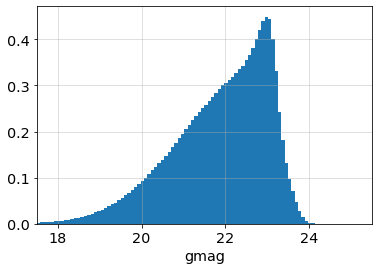

1st, 5th, 10th, 50th, 90th, 95th, 99th percentiles:
[18.67 19.71 20.26 22.11 23.16 23.32 23.63]


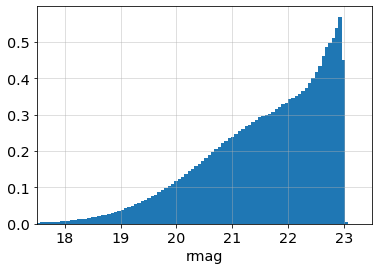

1st, 5th, 10th, 50th, 90th, 95th, 99th percentiles:
[18.49 19.5  20.03 21.81 22.83 22.92 22.99]


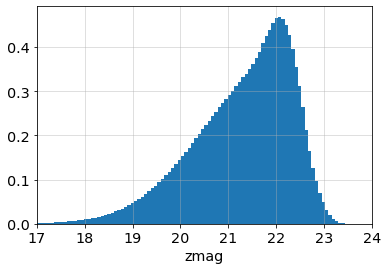

1st, 5th, 10th, 50th, 90th, 95th, 99th percentiles:
[18.36 19.35 19.85 21.5  22.45 22.62 22.93]


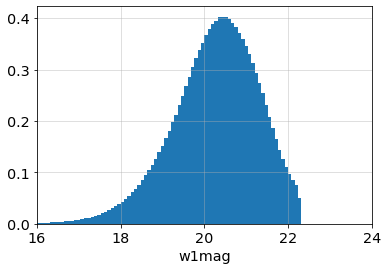

1st, 5th, 10th, 50th, 90th, 95th, 99th percentiles:
[17.46 18.45 18.92 20.35 21.52 21.79 22.16]


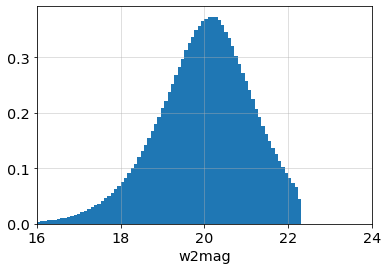

1st, 5th, 10th, 50th, 90th, 95th, 99th percentiles:
[16.92 17.98 18.5  20.06 21.39 21.73 22.14]
GAIA fraction: 25.1%


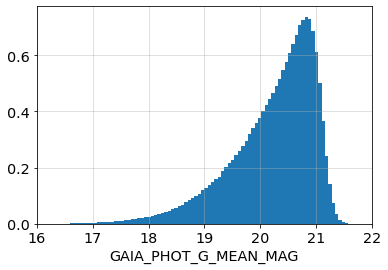

1st, 5th, 10th, 50th, 90th, 95th, 99th percentiles:
[17.87 18.75 19.17 20.41 21.01 21.11 21.26]


In [10]:
col_list = ['gmag', 'rmag', 'zmag', 'w1mag', 'w2mag', 'GAIA_PHOT_G_MEAN_MAG']
xlims = [[17.5, 25.5], [17.5, 23.5], [17, 24.], [16, 24], [16, 24], [16, 22]]

for index in range(len(col_list)):
    col = col_list[index]
    v = cat[col]
    mask = np.isfinite(v)
    if col=='GAIA_PHOT_G_MEAN_MAG':
        mask &= cat[col]!=0
        print('GAIA fraction: {:.1f}%'.format(100*np.sum(mask)/len(mask)))
    v = v[mask]
    plt.hist(v, 100, range=xlims[index], density=True)
    plt.xlim(*xlims[index])
    plt.xlabel(col)
    plt.grid(alpha=0.5)
    plt.show()
    print('1st, 5th, 10th, 50th, 90th, 95th, 99th percentiles:')
    print(np.nanpercentile(v, [1, 5, 10, 50, 90, 95, 99]))

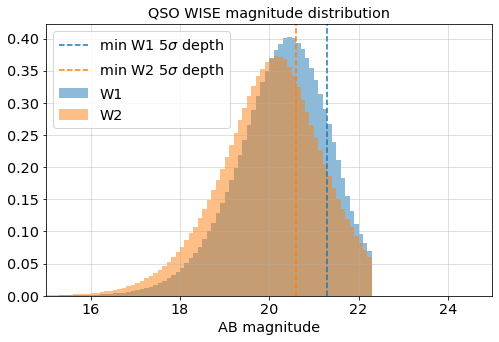

In [11]:
col_list = ['w1mag', 'w2mag']
xlims = [[15, 25], [15, 25]]

plt.figure(figsize=(8, 5))
v = cat['w1mag']
mask = np.isfinite(v)
v = v[mask]
plt.hist(v, 100, range=xlims[0], density=True, alpha=0.5, label='W1')
v = cat['w2mag']
mask = np.isfinite(v)
v = v[mask]
plt.hist(v, 100, range=xlims[0], density=True, alpha=0.5, label='W2')
plt.axvline(21.3, color='C0', ls='--', label=r'min W1 5$\sigma$ depth')
plt.axvline(20.6, color='C1', ls='--', label=r'min W2 5$\sigma$ depth')
plt.xlim(*xlims[0])
plt.xlabel('AB magnitude')
plt.legend()
plt.grid(alpha=0.5)
plt.title('QSO WISE magnitude distribution')
plt.show()